Trasformazione dei dati in corso...
Calcolo dell'Elbow Method in corso...
 -> K=2 completato (Inerzia: 2075150)
 -> K=3 completato (Inerzia: 1972119)
 -> K=4 completato (Inerzia: 1895501)
 -> K=5 completato (Inerzia: 1842311)
 -> K=6 completato (Inerzia: 1796338)
 -> K=7 completato (Inerzia: 1758092)
 -> K=8 completato (Inerzia: 1723531)
 -> K=9 completato (Inerzia: 1692252)
 -> K=10 completato (Inerzia: 1664128)


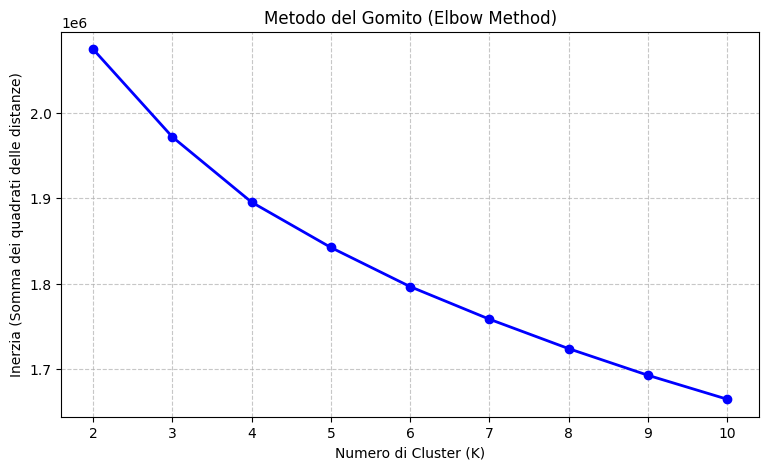

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import sys
import os

# 1. Capiamo dove si trova il notebook (es. dentro la cartella 'notebooks')
cartella_corrente = os.getcwd()

# 2. Facciamo UN PASSO INDIETRO per trovare la cartella principale del progetto
cartella_principale = os.path.dirname(cartella_corrente)

# 3. Facciamo UN ALTRO PASSO INDIETRO per trovare la root principale
cartella_root = os.path.dirname(cartella_principale)

# 4. Aggiungiamo la cartella principale al radar di Python
if cartella_principale not in sys.path:
    sys.path.append(cartella_principale)

# Importiamo il preprocessore dal file esterno
from utils.preprocessing import build_preprocessor

dataset_path = os.path.join(cartella_root, 'data', 'processed', 'adapted_dataset.csv')

df_users = pd.read_csv(dataset_path)

print("Trasformazione dei dati in corso...")
preprocessor = build_preprocessor()
X_processed = preprocessor.fit_transform(df_users)

# Calcolo dell'Inerzia
inertias = []
K_range = range(2, 11)

print("Calcolo dell'Elbow Method in corso...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    inertias.append(kmeans.inertia_)
    print(f" -> K={k} completato (Inerzia: {kmeans.inertia_:.0f})")

# Disegno del grafico
plt.figure(figsize=(9, 5))
plt.plot(K_range, inertias, marker='o', linestyle='-', color='b', linewidth=2)
plt.title('Metodo del Gomito (Elbow Method)')
plt.xlabel('Numero di Cluster (K)')
plt.ylabel('Inerzia (Somma dei quadrati delle distanze)')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.7)

# MOSTRA IL GRAFICO INVECE DI SALVARLO
plt.show()